# Transformers and Attention-Based Deep Networks Assignment - 1

Made by Khudiakova Kseniia, e278979

## Setup

and connection to wandb


In [1]:
!pip install transformers wandb seaborn matplotlib pandas -q

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid")

sentiment_order = ["negative", "neutral", "positive"]
palette = dict(zip(sentiment_order, sns.color_palette("viridis", 3)))
colors = [palette[s] for s in sentiment_order]

def shorten_label(label, max_length=30):
    if len(str(label)) > max_length:
        return str(label)[:max_length] + "..."
    return str(label)

In [3]:
import wandb

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()


wandb.login(key=user_secrets.get_secret("WANDB_API_KEY"))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: e278979 (e278979-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Import data


In [4]:
train_path = "/kaggle/input/datasets/khudiakovakseniia/transformers-ass1/train.csv"
test_path  = "/kaggle/input/datasets/khudiakovakseniia/transformers-ass1/test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

In [5]:
print("Train dataset sample:")
display(train_df.head())


Train dataset sample:


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


In [6]:
print("test dataset sample:")
display(test_df.head())


test dataset sample:


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Shopping,Pricing and Discounts,Discounts through exchange offers,Pricing and Discounts -> Discounts through exc...,negative,Appliances,Hand Blender,less,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
1,Login and Account,Account Reactivation and Deactivation,Reactivating an inactive account,Account Reactivation and Deactivation -> React...,negative,Men/Women/Kids,Wrist Watch,medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
2,Cancellations and returns,Cash on Delivery (CoD) Refunds,Refund timelines for Cash on Delivery returns,Cash on Delivery (CoD) Refunds -> Refund timel...,negative,Appliances,Induction Cooktop,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
3,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as deli...,negative,Men/Women/Kids,Sunglas,high,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
4,Cancellations and returns,Pickup and Shipping,Reimbursement of courier charges for return,Pickup and Shipping -> Reimbursement of courie...,negative,Electronics,Computer Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...


## Exploratory Data Analysis

Goal of this part - understand data. I will divide into 4 parts: overview, sentiment(target) distribution, conversation nalysis, conection between target and features 

### Dataset Overview


In [7]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nDataset info:")
train_df.info()

print("\nMissing values:")
display(train_df.isnull().sum())


Train shape: (970, 11)
Test shape: (30, 11)

Columns:
Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   issue_area                   970 non-null    object
 1   issue_category               970 non-null    object
 2   issue_sub_category           970 non-null    object
 3   issue_category_sub_category  970 non-null    object
 4   customer_sentiment           970 non-null    object
 5   product_category             970 non-null    object
 6   product_sub_category         970 non-null    object
 7   issue_complex

issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64

### Target Distribution

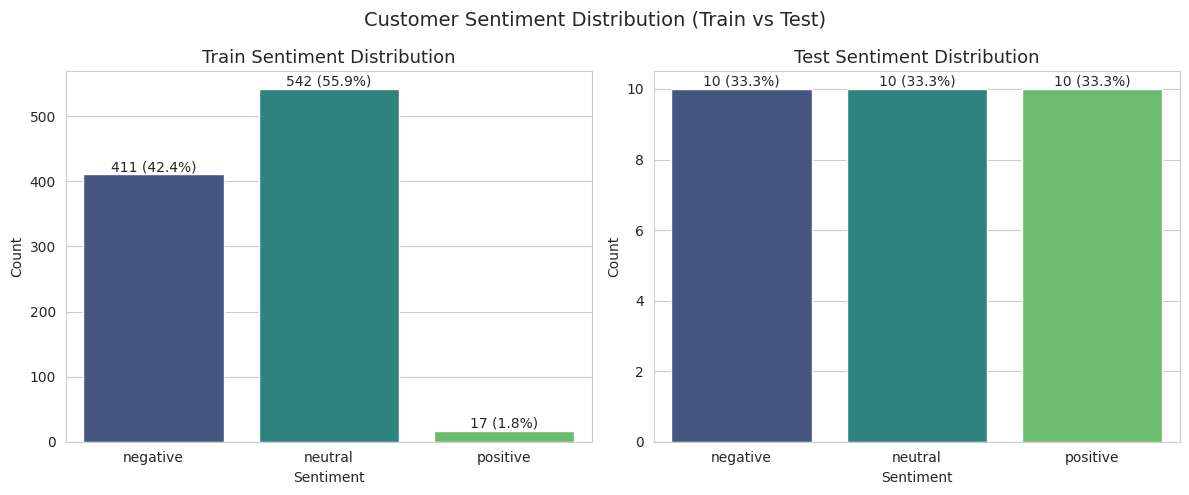

In [8]:
sentiment_order = ["negative", "neutral", "positive"]
palette = dict(zip(sentiment_order, sns.color_palette("viridis", 3)))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ---- TRAIN ----
ax1 = sns.countplot(
    data=train_df,
    x="customer_sentiment",
    hue="customer_sentiment",
    order=sentiment_order,
    palette=palette,
    ax=axes[0]
)

axes[0].set_title("Train Sentiment Distribution", fontsize=13)
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

total_train = len(train_df)

for p in ax1.patches:
    count = int(p.get_height())
    percent = 100 * count / total_train
    ax1.annotate(
        f"{count} ({percent:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

# ---- TEST ----
ax2 = sns.countplot(
    data=test_df,
    x="customer_sentiment",
    hue="customer_sentiment",
    order=sentiment_order,
    palette=palette,
    ax=axes[1]
)

axes[1].set_title("Test Sentiment Distribution", fontsize=13)
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")

total_test = len(test_df)

for p in ax2.patches:
    count = int(p.get_height())
    percent = 100 * count / total_test
    ax2.annotate(
        f"{count} ({percent:.1f}%)",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.suptitle("Customer Sentiment Distribution (Train vs Test)", fontsize=14)

plt.tight_layout()
plt.show()

As we can see, sentiment in training data is hughly imbalanced. It will lead to bias towards not "positive" in model predictions

### Conversation Length Analysis

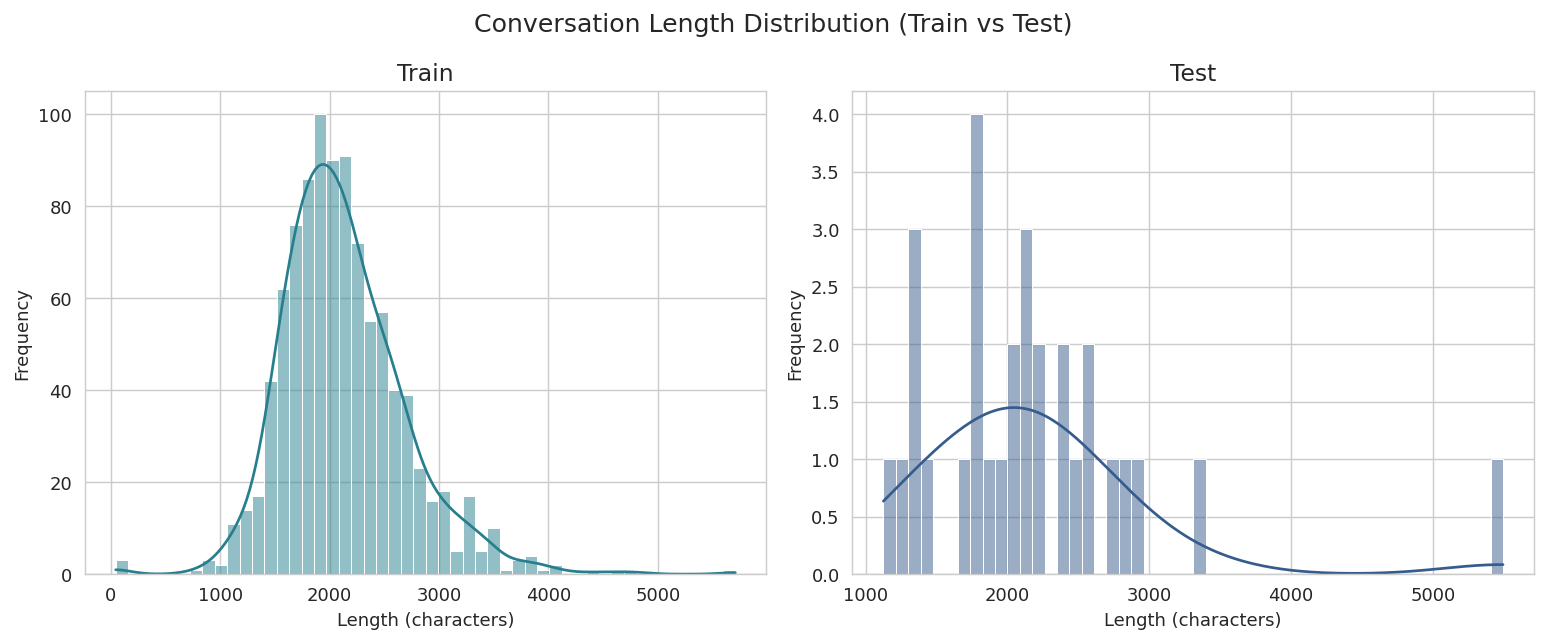

In [9]:

train_df["conversation_length"] = train_df["conversation"].apply(len)
test_df["conversation_length"] = test_df["conversation"].apply(len)

plt.rcParams["figure.dpi"] = 130
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

bins = 50
max_len = max(train_df["conversation_length"].max(), test_df["conversation_length"].max())

# ---- TRAIN ----
sns.histplot(
    train_df["conversation_length"],
    bins=bins,
    kde=True,
    color=sns.color_palette("viridis")[2],
    ax=axes[0]
)

axes[0].set_title("Train", fontsize=13)
axes[0].set_xlabel("Length (characters)")
axes[0].set_ylabel("Frequency")

# ---- TEST ----
sns.histplot(
    test_df["conversation_length"],
    bins=bins,
    kde=True,
    color=sns.color_palette("viridis")[1],
    ax=axes[1]
)

axes[1].set_title("Test", fontsize=13)
axes[1].set_xlabel("Length (characters)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Conversation Length Distribution (Train vs Test)", fontsize=14)

plt.tight_layout()
plt.show()


In [10]:
# ===== STATISTICS =====

print("TRAIN")
print(train_df["conversation_length"].describe())
print("Max:", train_df["conversation_length"].max())
print("Median:", train_df["conversation_length"].median())

print("\nTEST")
print(test_df["conversation_length"].describe())
print("Max:", test_df["conversation_length"].max())
print("Median:", test_df["conversation_length"].median())

TRAIN
count     970.000000
mean     2129.284536
std       564.751035
min        46.000000
25%      1760.250000
50%      2058.500000
75%      2430.000000
max      5708.000000
Name: conversation_length, dtype: float64
Max: 5708
Median: 2058.5

TEST
count      30.000000
mean     2178.566667
std       828.185873
min      1125.000000
25%      1772.500000
50%      2092.500000
75%      2459.250000
max      5496.000000
Name: conversation_length, dtype: float64
Max: 5496
Median: 2092.5


To sum up:
1) kde at test plot looks bad because of small size of test dataset
2) means and medians are very similar in both datasets, so distributions are almost the same. It is also visible through the shape of distributions
3) although quantiles are approx similar too, test dataset has less extra short conversations. we will see whether it will affect predictions or not

### Connections Feature-Target

#### General remarks

In [11]:
target = "customer_sentiment"
cat_features = [
    "issue_area",
    "issue_category",
    "issue_sub_category",
    "product_category",
    "product_sub_category",
    "issue_complexity",
    "agent_experience_level"
]
min_samples = 15 # ignore categories because for some of them it is 100% 1 type if santiment per category

global_dist = train_df[target].value_counts(normalize=True)

results = []

for feature in cat_features:

    counts = train_df[feature].value_counts()

    valid_categories = counts[counts >= min_samples].index

    df_filtered = train_df[train_df[feature].isin(valid_categories)]

    if len(df_filtered) == 0:
        continue

    ct = pd.crosstab(df_filtered[feature], df_filtered[target], normalize="index")

    diffs = []

    for cat in ct.index:

        diff = np.abs(ct.loc[cat] - global_dist).sum() / 2
        weight = counts[cat] / len(train_df)

        diffs.append(diff * weight)

    score = np.sum(diffs)

    if score < 0.03:
        relation = "no relation"
    elif score < 0.07:
        relation = "weak relation"
    elif score < 0.12:
        relation = "moderate relation"
    else:
        relation = "strong relation"

    results.append({
        "feature": feature,
        "relation_score": round(score,4),
        "relation_label": relation,
        "num_categories": train_df[feature].nunique(),
        "categories_used": len(valid_categories)
    })

results_df = pd.DataFrame(results).sort_values("relation_score", ascending=False)

results_df

,feature,relation_score,relation_label,num_categories,categories_used
1,issue_category,0.2262,strong relation,40,22
0,issue_area,0.1693,strong relation,6,6
4,product_sub_category,0.0858,moderate relation,50,43
6,agent_experience_level,0.0313,weak relation,3,3
2,issue_sub_category,0.0302,weak relation,109,4
3,product_category,0.0168,no relation,3,3
5,issue_complexity,0.0120,no relation,3,3


To overview, we have 3 features that have some visible patterns of sentiment distribution and 2 features with weak relation. Let's see it at plots!

#### issue_area

The feature shows a clear pattern: more difficult types of issues lead to more negative feedback. Interestingly, the area with the largest negative portion also contains some positive feedback. 

**What to do** : keep this feature for modeling, it is informative.

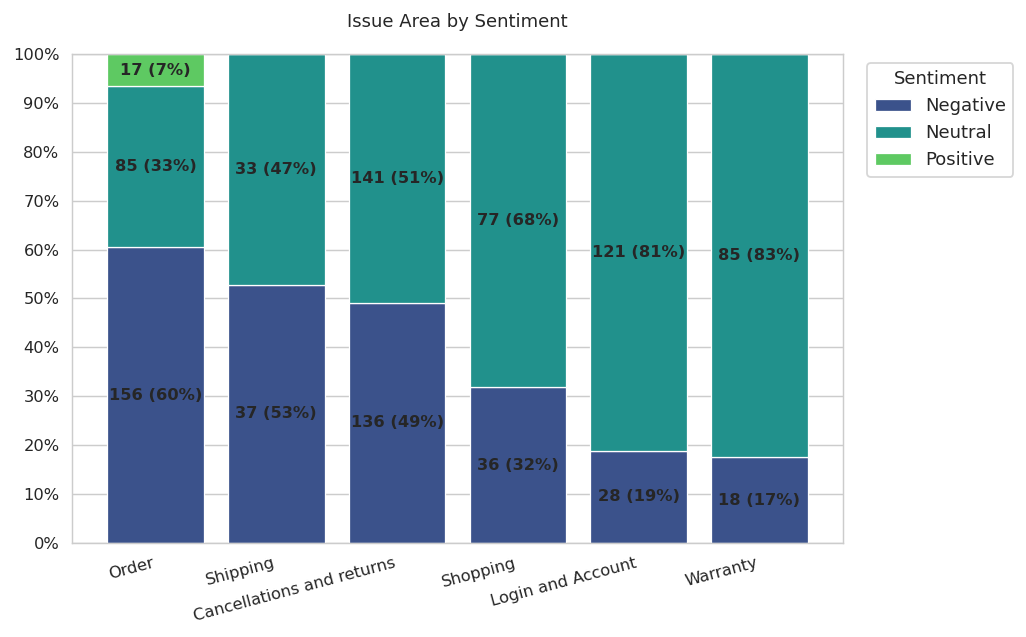

In [12]:
feature = "issue_area"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(ct.index))
width = 0.8

colors = [palette[s] for s in sentiment_order]
bottom = np.zeros(len(ct.index))

for i, sentiment in enumerate(sentiment_order):
    bars = ax.bar(x, ct[sentiment].values, width, bottom=bottom, 
                  color=colors[i], edgecolor='white', linewidth=0.7,
                  label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.02:
            count = ct_counts.loc[ct.index[j], sentiment]
            ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2,
                   f'{count} ({val:.0%})', ha='center', va='center', fontsize=9, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=10, pad=15)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(ct.index, rotation=15, ha='right')
ax.tick_params(labelsize=9)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### issue_category

This is feature that supposingly has strongest relation to target. Interestingly, here I can not identify strong pattern, since we have categories with only postive/neutral/negative sentiment, simultaneously with categories with mixed neutral-negative and neutral-positive feedback. In mixed sentiment categories, with netral-negative we have categories where it is mostly negative and also where it is mostly neutral, hovewer in mexd neutral-positive always neutral portion dominates. 

Actually we can see some pattern, if issue have specific (easy) steps to solve, feedback is positive ("placing an order"), while in categories with no solution ("availability of faster delivery", "product availability", etc) negative sentiment dominates. I think it is strong relation, "the easier solution , the more positivier feedback"

**What to do:** keep and encode carefully

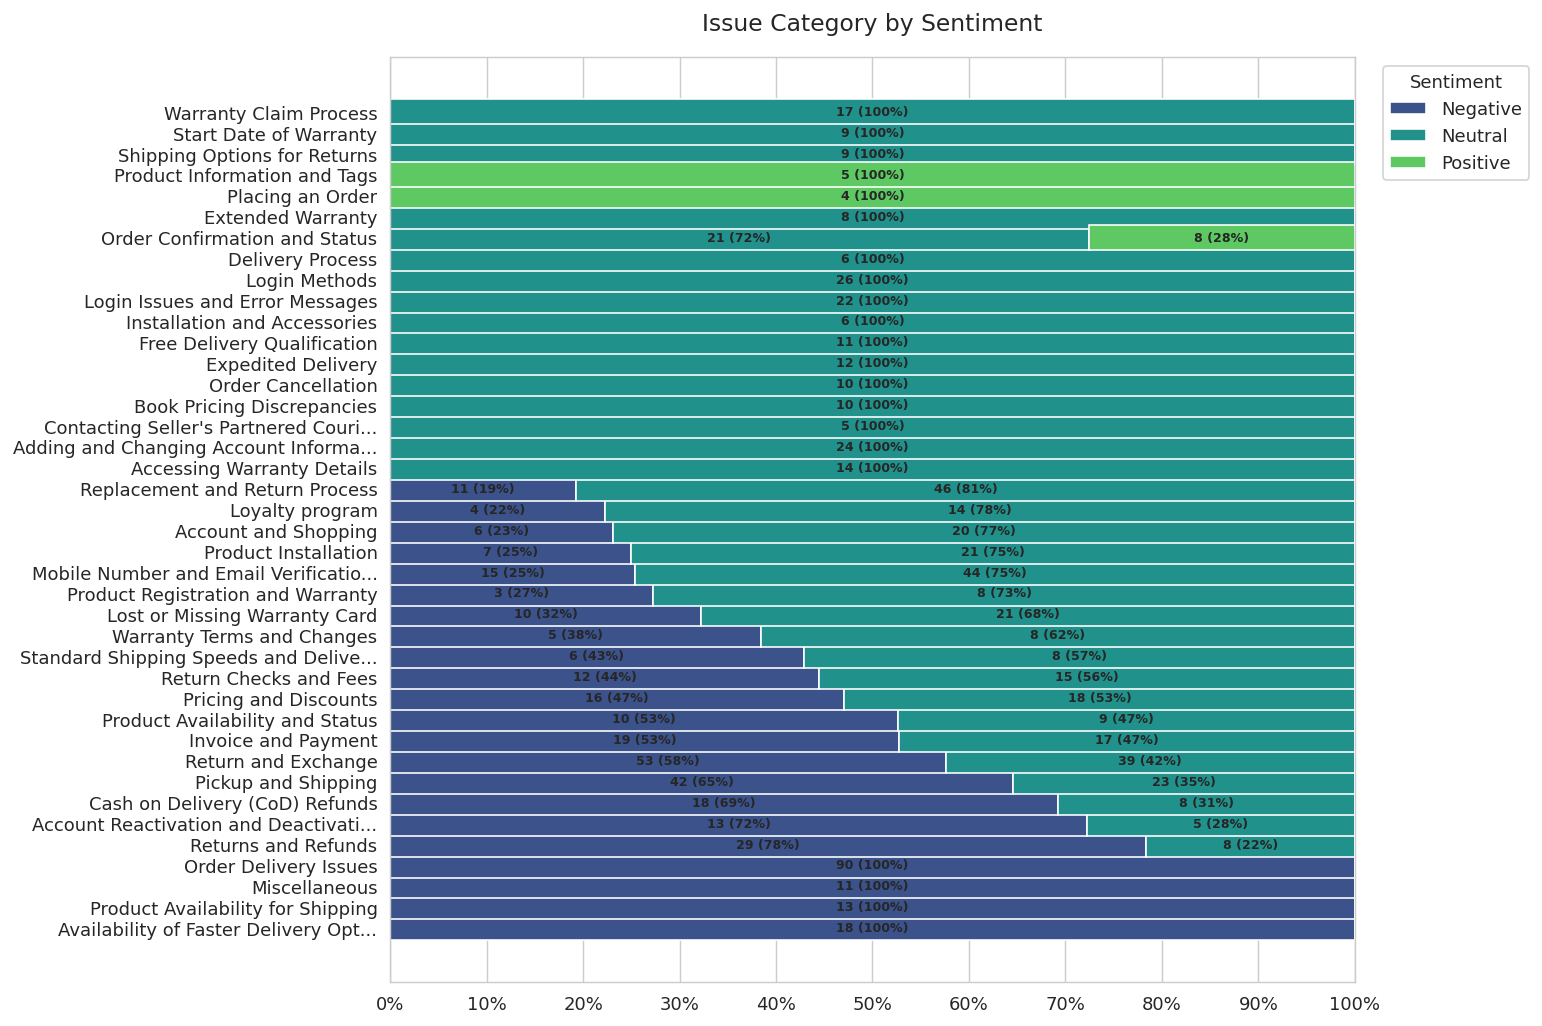

In [13]:
feature = "issue_category"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

original_index = ct.index.copy()
short_index = [shorten_label(idx, 35) for idx in ct.index]
ct.index = short_index

fig, ax = plt.subplots(figsize=(12, 8))

bottom = np.zeros(len(ct))
colors = [palette[s] for s in sentiment_order]

for i, sentiment in enumerate(sentiment_order):
    bars = ax.barh(ct.index, ct[sentiment].values, height = 1.2, left=bottom, color=colors[i], 
                   edgecolor='white', linewidth=0.9, label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.02:
            count = ct_counts.loc[original_index[j], sentiment]
            ax.text(bottom[j] + val/2, j, f'{count} ({val:.0%})', 
                   ha='center', va='center', fontsize=7, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=13, pad=15)
ax.set_xlim(0, 1)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### issue_sub_category

That feature actually has weak or almost no relation, since all of the categories are eather 100% positive or 100% negative or 100% neutral. In other words, same proportions in all categories means no dependency pattern.

**What t do**: not use as prediction feature

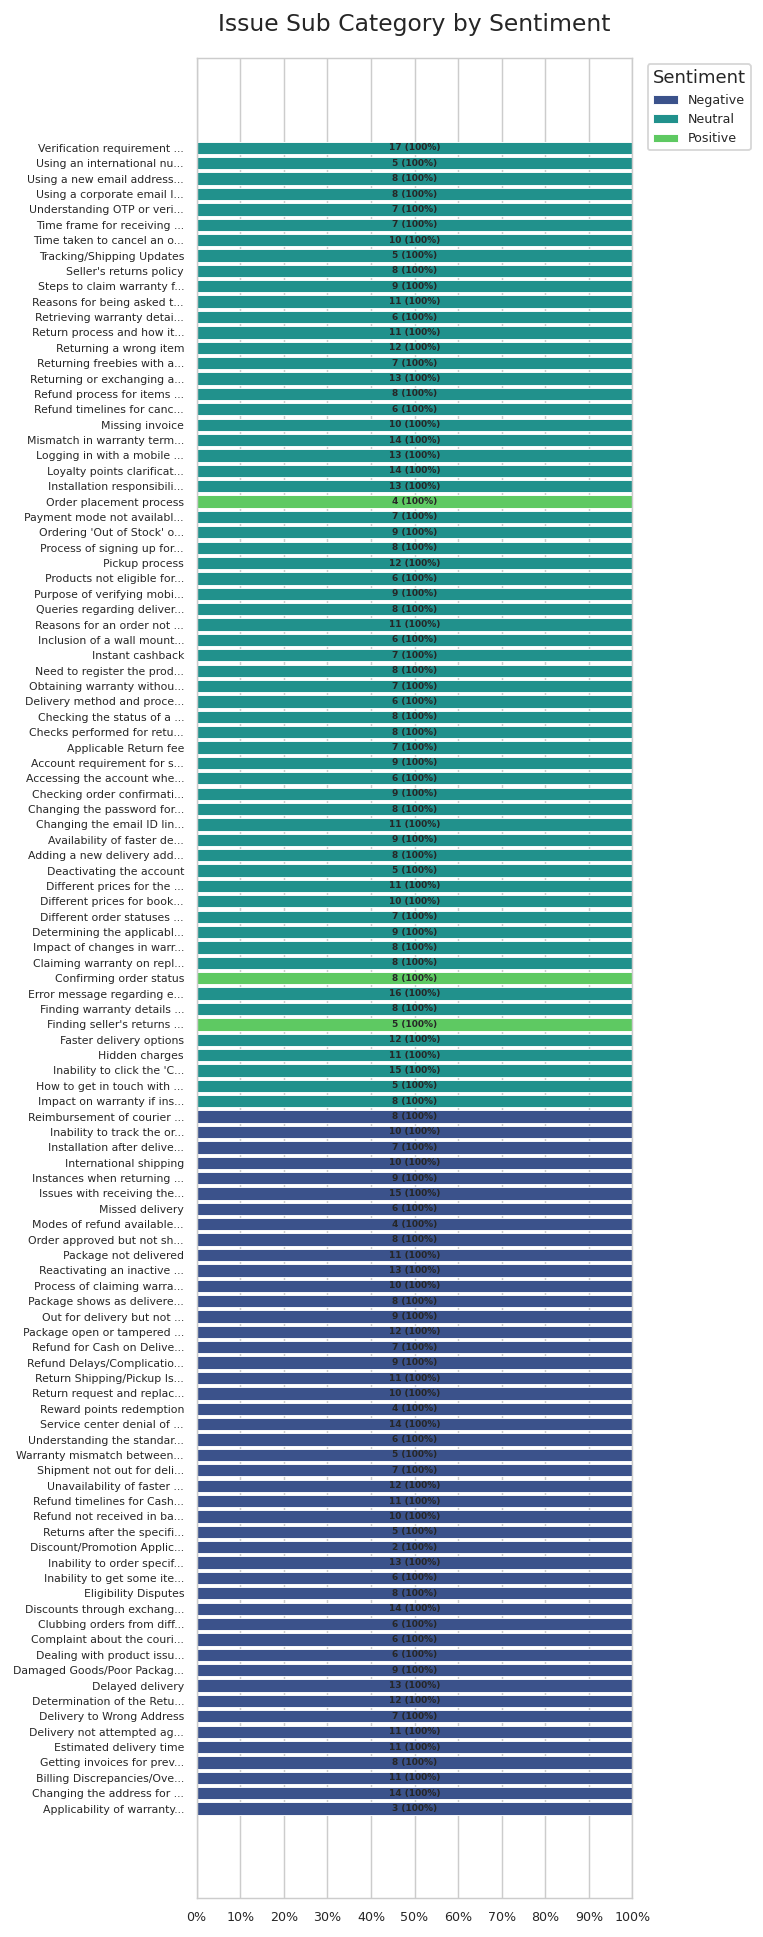

In [14]:
feature = "issue_sub_category"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

original_index = ct.index.copy()

short_index = [shorten_label(idx, 25) for idx in ct.index]
ct.index = short_index
bar_height = 0.8

fig, ax = plt.subplots(figsize=(6, 15))

bottom = np.zeros(len(ct))
colors = [palette[s] for s in sentiment_order]

for i, sentiment in enumerate(sentiment_order):
    bars = ax.barh(ct.index, ct[sentiment].values, height=bar_height, left=bottom, 
                   color=colors[i], edgecolor='white', linewidth=0.5, 
                   label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.03:
            count = ct_counts.loc[original_index[j], sentiment]
            ax.text(bottom[j] + val/2, j, f'{count} ({val:.0%})', 
                   ha='center', va='center', fontsize=5, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=13, pad=15)
ax.set_xlim(0, 1)
ax.set_xlim(0, 1)
ax.tick_params(axis='y', labelsize=6)
ax.tick_params(axis='x', labelsize=7)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

#### product_category

This feature also has the same proportions along all categorcategories, so no relation to target

**What to do:** do not use sincve has no predictive value


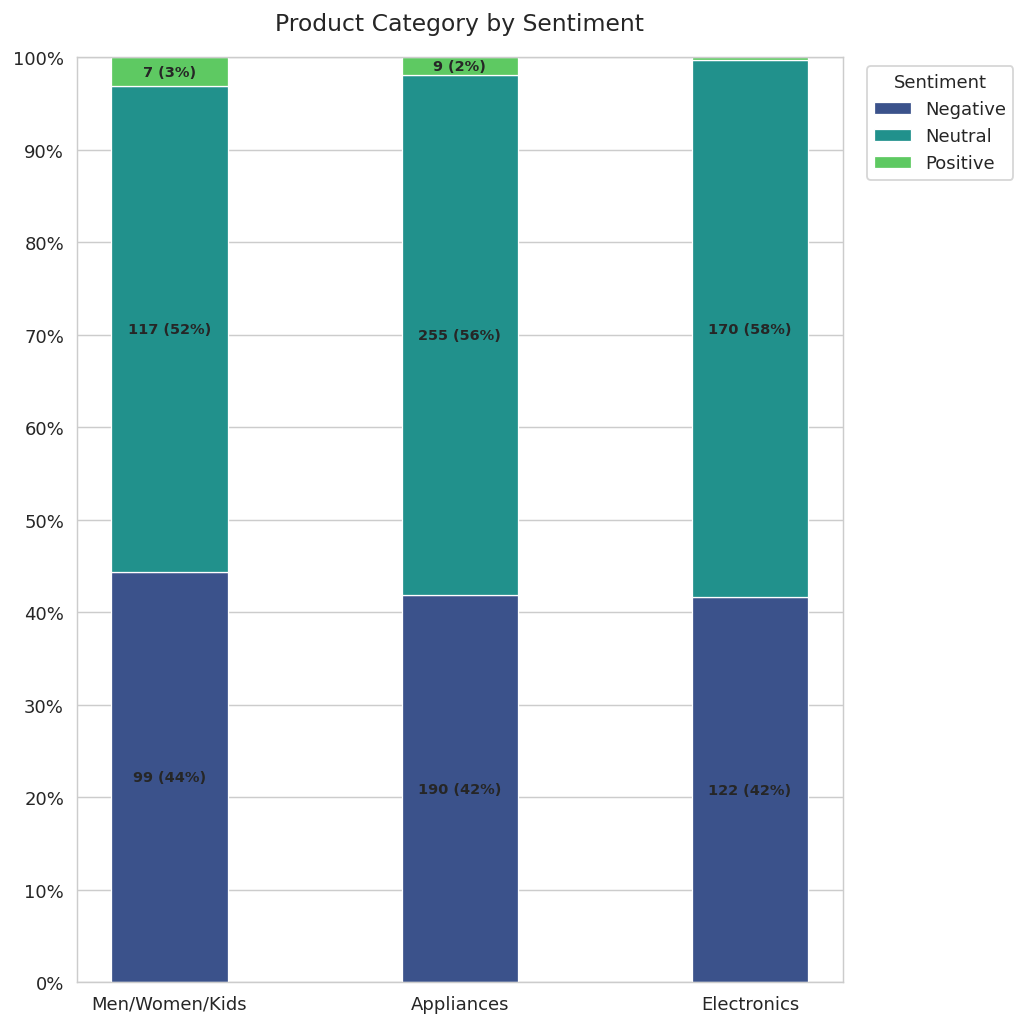

In [15]:
feature = "product_category"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))

x = np.arange(len(ct.index))
width = 0.4
bottom = np.zeros(len(ct.index))
colors = [palette[s] for s in sentiment_order]

for i, sentiment in enumerate(sentiment_order):
    bars = ax.bar(x, ct[sentiment].values, width, bottom=bottom, 
                  color=colors[i], edgecolor='white', linewidth=0.7,
                  label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.01:
            count = ct_counts.loc[ct.index[j], sentiment]
            ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2,
                   f'{count} ({val:.0%})', ha='center', va='center', fontsize=8, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=13, pad=15)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(ct.index)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### product_sub_category

According to statistics, this feature has moderate connection. And I agree with statistics, since we can see the pattern, but I could not identify it, because it is not clear why "baby food", "backpack", and "ceiling fan" have the more than a half negative feedback, while "laptop", "water geyser", "headphone" are top-3 neutral sentiments. And positive sentiment has no pattern at all, just randomly  for example "washing machine" and "sunglass" got 1-2% of positives.

**What to do:** keep but possibly drop, since relation is not strong

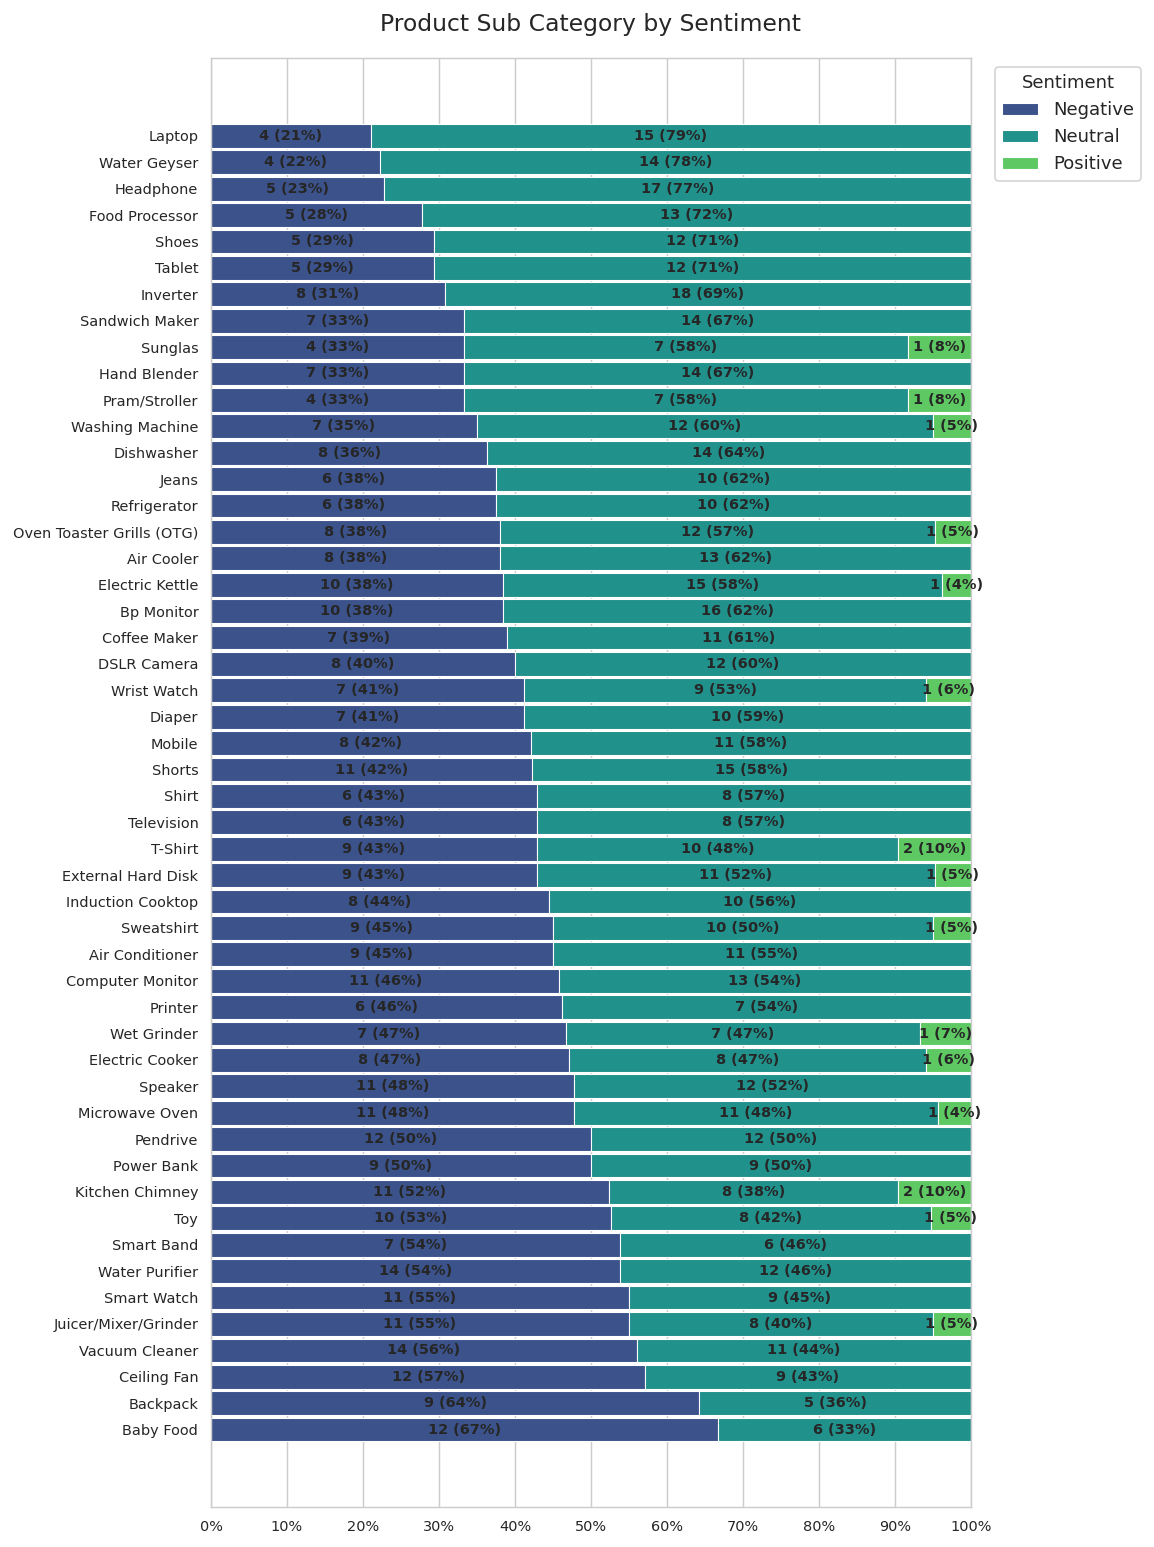

In [16]:
feature = "product_sub_category"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

original_index=ct.index

short_index = [shorten_label(idx, 25) for idx in ct.index]
ct.index = short_index

fig, ax = plt.subplots(figsize=(9, 12))

bottom = np.zeros(len(ct))
colors = [palette[s] for s in sentiment_order]

for i, sentiment in enumerate(sentiment_order):
    bars = ax.barh(ct.index, ct[sentiment].values, height = 0.9,left=bottom, color=colors[i], 
                   edgecolor='white', linewidth=0.6, label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.02:
            count = ct_counts.loc[original_index[j], sentiment]
            ax.text(bottom[j] + val/2, j, f'{count} ({val:.0%})', 
                   ha='center', va='center', fontsize=8, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=13, pad=15)
ax.set_xlim(0, 1)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### issue_complexity

Surprisingly, issue_complexity has no relation to users feedback, it has almost similar distribution for all complexities. Well, I guess it is because support service team is skilled enough to solve complex and easy problems with almost the same success rate :)

**What to do:** ignore in predictions

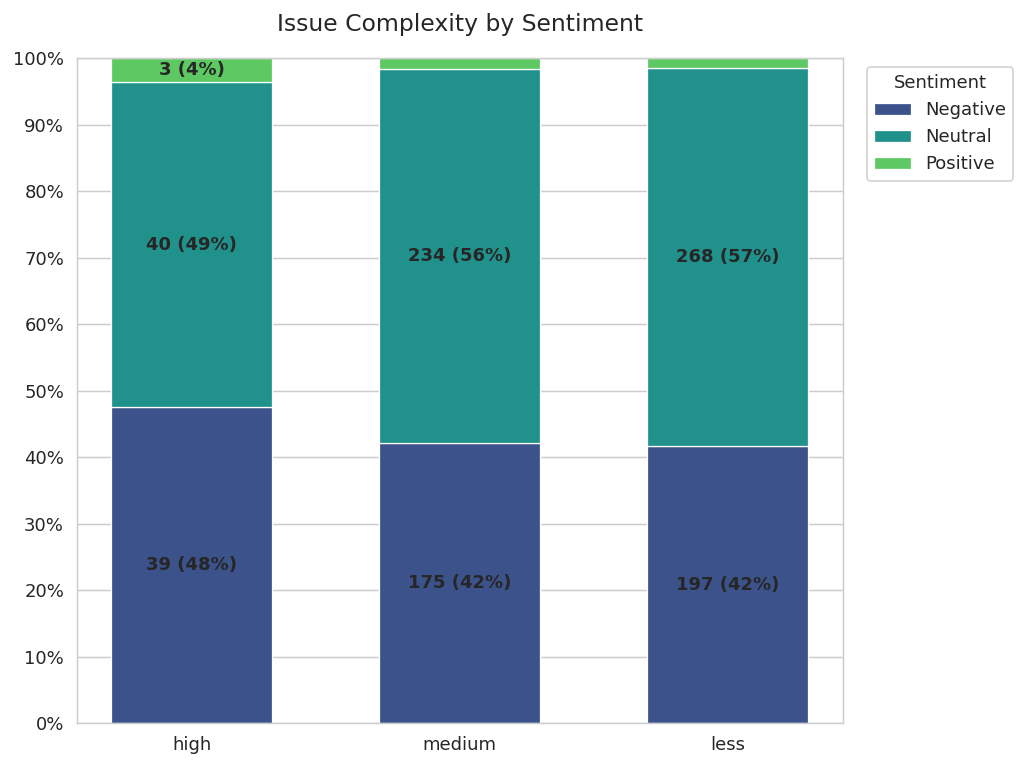

In [17]:
feature = "issue_complexity"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(ct.index))
width = 0.6
bottom = np.zeros(len(ct.index))
colors = [palette[s] for s in sentiment_order]

for i, sentiment in enumerate(sentiment_order):
    bars = ax.bar(x, ct[sentiment].values, width, bottom=bottom, 
                  color=colors[i], edgecolor='white', linewidth=0.7,
                  label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.02:
            count = ct_counts.loc[ct.index[j], sentiment]
            ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2,
                   f'{count} ({val:.0%})', ha='center', va='center', fontsize=10, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=13, pad=15)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(ct.index)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### agent_experience_level

This feature is also not correlating with user sentiment, since distributions is roughly similar for inexperienced/junior/experienced agents. Although, it is interesting that inexperienced agents got the least proportion of negative feedback, while juniors has more. I can be also because of number of juniours agents are larger than anybody else

**What to do:** do not consider as predictive feature

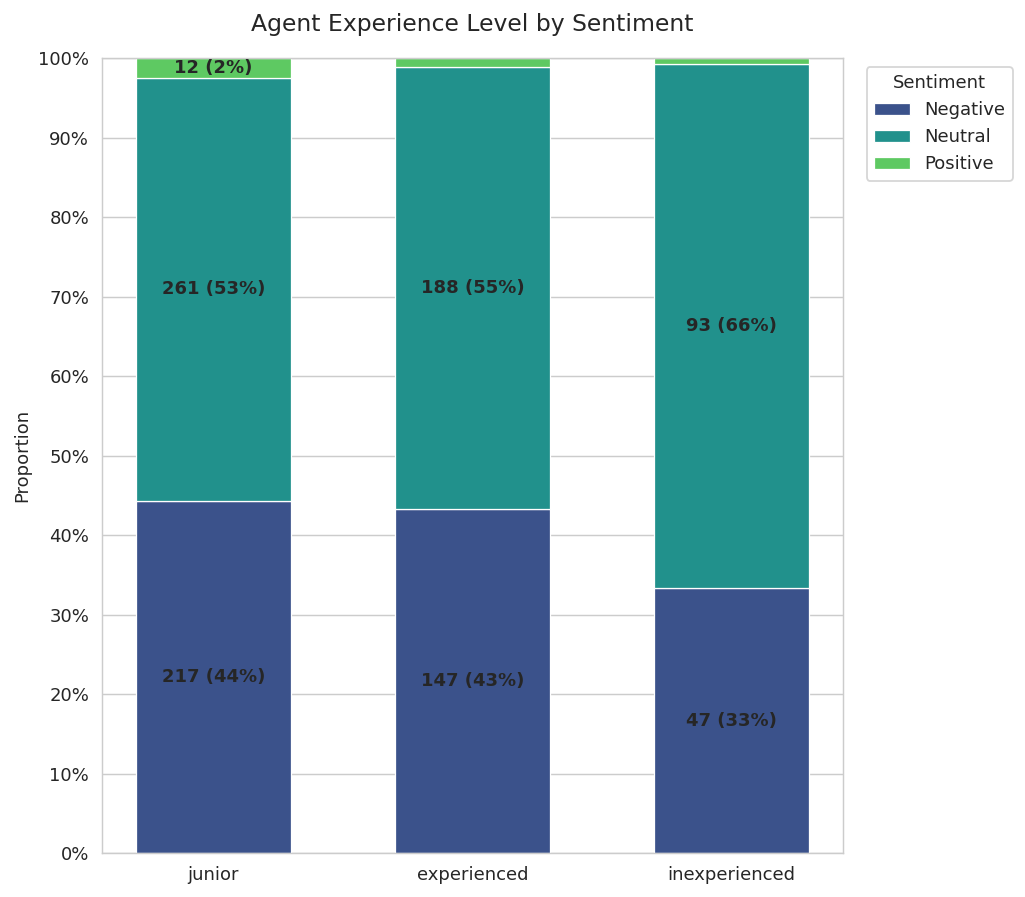

In [18]:
feature = "agent_experience_level"

ct_counts = pd.crosstab(train_df[feature], train_df["customer_sentiment"])
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)
ct = ct_props.sort_values("negative", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))

x = np.arange(len(ct.index))
width = 0.6
bottom = np.zeros(len(ct.index))
colors = [palette[s] for s in sentiment_order]

for i, sentiment in enumerate(sentiment_order):
    bars = ax.bar(x, ct[sentiment].values, width, bottom=bottom, 
                  color=colors[i], edgecolor='white', linewidth=0.7,
                  label=sentiment.capitalize())
    
    for j, (val, bar) in enumerate(zip(ct[sentiment].values, bars)):
        if val > 0.02:
            count = ct_counts.loc[ct.index[j], sentiment]
            ax.text(bar.get_x() + bar.get_width()/2., bottom[j] + val/2,
                   f'{count} ({val:.0%})', ha='center', va='center', 
                   fontsize=10, fontweight='bold')
    
    bottom += ct[sentiment].values

ax.set_title(f'{feature.replace("_", " ").title()} by Sentiment', fontsize=13, pad=15)
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(ct.index)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Results of EDA

To conclude, i will definitely keep and use issue_category, issue_area and possibly product_sub_category as features, since they have visible pattern in relations to user sentiment.

## Preprocessing

In [19]:
# ===== preprocessing congig =====

preprocessing_config = {
    "split_dialog": "both",  # 'both', 'customer', 'agent'
    "truncation_side": "right",  # 'left' - cut beginning, 'right' - cut end
    "max_length": 512,
}


### 1. Drop columns

Based on EDA and common sence

In [20]:
useful_columns = [
    "conversation",
    "issue_area",
    "issue_category",
    "product_sub_category",
    "customer_sentiment",
    "conversation_length"
]

train_df = train_df[useful_columns].copy()
test_df = test_df[useful_columns].copy()

In [21]:
train_df.head()

,conversation,issue_area,issue_category,product_sub_category,customer_sentiment,conversation_length
0,Agent: Thank you for calling BrownBox Customer...,Login and Account,Mobile Number and Email Verification,Oven Toaster Grills (OTG),neutral,1487
1,Agent: Thank you for calling BrownBox customer...,Cancellations and returns,Pickup and Shipping,Computer Monitor,neutral,1546
2,Agent: Thank you for calling BrownBox Customer...,Cancellations and returns,Replacement and Return Process,Juicer/Mixer/Grinder,neutral,2417
3,"Customer: Hi, I am facing an issue while loggi...",Login and Account,Login Issues and Error Messages,Water Purifier,neutral,2096
4,Agent: Thank you for contacting BrownBox custo...,Order,Order Delivery Issues,Bp Monitor,negative,3034


In [22]:
test_df.head()

,conversation,issue_area,issue_category,product_sub_category,customer_sentiment,conversation_length
0,Agent: Thank you for calling BrownBox Customer...,Shopping,Pricing and Discounts,Hand Blender,negative,1997
1,Agent: Thank you for calling BrownBox Customer...,Login and Account,Account Reactivation and Deactivation,Wrist Watch,negative,2394
2,Agent: Thank you for calling BrownBox Customer...,Cancellations and returns,Cash on Delivery (CoD) Refunds,Induction Cooktop,negative,2120
3,Agent: Thank you for calling BrownBox Customer...,Order,Order Delivery Issues,Sunglas,negative,3377
4,Agent: Thank you for calling BrownBox Customer...,Cancellations and returns,Pickup and Shipping,Computer Monitor,negative,2382


### 2. Map target

It is easier to classify between numerical labels, so we need to map sentiment into 3 categories

In [23]:
sentiment_mapping = {"negative": 0, "neutral": 1, "positive": 2}
train_df['target'] = train_df['customer_sentiment'].map(sentiment_mapping)
test_df['target'] = test_df['customer_sentiment'].map(sentiment_mapping)

train_df.drop(['customer_sentiment'], axis=1, inplace=True)
test_df.drop(['customer_sentiment'], axis=1, inplace=True)

In [24]:
train_df.head()

,conversation,issue_area,issue_category,product_sub_category,conversation_length,target
0,Agent: Thank you for calling BrownBox Customer...,Login and Account,Mobile Number and Email Verification,Oven Toaster Grills (OTG),1487,1
1,Agent: Thank you for calling BrownBox customer...,Cancellations and returns,Pickup and Shipping,Computer Monitor,1546,1
2,Agent: Thank you for calling BrownBox Customer...,Cancellations and returns,Replacement and Return Process,Juicer/Mixer/Grinder,2417,1
3,"Customer: Hi, I am facing an issue while loggi...",Login and Account,Login Issues and Error Messages,Water Purifier,2096,1
4,Agent: Thank you for contacting BrownBox custo...,Order,Order Delivery Issues,Bp Monitor,3034,0


### 3. Clean conversations

We need to ommit extra spaces and \n's and other extra characters, to save space

Also I decided to try to split dialog by roles (agent/customer), so I can use only one of them to predict

In [25]:
def clean_text(text):
    text = text.replace("\n", " ").strip()
    return text

def split_agent_customer(text, keep_mode='both'):

    text = clean_text(text)
    
    if keep_mode == 'both':
        return text.lower()
    
    parts = []
    current_speaker = None
    current_text = []
    
    lines = text.split('  ')
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        if line.lower().startswith('customer:'):
            if current_speaker == 'customer' and current_text:
                parts.append(('customer', ' '.join(current_text)))
            current_speaker = 'customer'
            current_text = [line[len('customer:'):].strip()]
        elif line.lower().startswith('agent:'):
            if current_speaker == 'agent' and current_text:
                parts.append(('agent', ' '.join(current_text)))
            current_speaker = 'agent'
            current_text = [line[len('agent:'):].strip()]
        else:
            if current_text:
                current_text.append(line)
    
    if current_speaker and current_text:
        parts.append((current_speaker, ' '.join(current_text)))
    
    if keep_mode == 'customer':
        result = ' '.join([text for speaker, text in parts if speaker == 'customer'])
    elif keep_mode == 'agent':
        result = ' '.join([text for speaker, text in parts if speaker == 'agent'])
    else:
        result = text.lower()
    
    return result.lower() if result else text.lower()


train_df['conversation_clean'] = train_df['conversation'].apply(clean_text).str.lower()
test_df['conversation_clean'] = test_df['conversation'].apply(clean_text).str.lower()


train_df.drop(['conversation'], axis=1, inplace=True)
test_df.drop(['conversation'], axis=1, inplace=True)

In [26]:
train_df.head()

,issue_area,issue_category,product_sub_category,conversation_length,target,conversation_clean
0,Login and Account,Mobile Number and Email Verification,Oven Toaster Grills (OTG),1487,1,agent: thank you for calling brownbox customer...
1,Cancellations and returns,Pickup and Shipping,Computer Monitor,1546,1,agent: thank you for calling brownbox customer...
2,Cancellations and returns,Replacement and Return Process,Juicer/Mixer/Grinder,2417,1,agent: thank you for calling brownbox customer...
3,Login and Account,Login Issues and Error Messages,Water Purifier,2096,1,"customer: hi, i am facing an issue while loggi..."
4,Order,Order Delivery Issues,Bp Monitor,3034,0,agent: thank you for contacting brownbox custo...


### 4. Encode categorial features

we will feed them to model, so need to clean them too and convert to understandable way for model

I will compare 4 encoding methods (LabelEncoder, One-hot, Target Encoding, and Ordinal Encoding with custom order) using Mutual Information (MI). MI measures how much information a feature contains about the target variable: higher values indicate a stronger dependency and therefore a more informative encoding

In [27]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

features = ['issue_area', 'issue_category', 'product_sub_category']
y = train_df['target']

results = []

for f in features:

    # -------- LabelEncoder --------
    le = LabelEncoder()
    X_le = le.fit_transform(train_df[f]).reshape(-1,1)
    mi_le = mutual_info_classif(X_le, y, discrete_features=True)[0]


    # -------- One-hot --------
    ohe = OneHotEncoder()
    X_ohe = ohe.fit_transform(train_df[[f]])
    mi_ohe = mutual_info_classif(X_ohe, y, discrete_features=True).mean()


    # -------- Target Encoding --------
    means = train_df.groupby(f)['target'].mean()
    X_te = train_df[f].map(means).values.reshape(-1,1)
    mi_te = mutual_info_classif(X_te, y)[0]


    # -------- Ordinal Encoding (custom order) --------
    order = means.sort_values().index.tolist()

    oe = OrdinalEncoder(categories=[order])
    X_oe = oe.fit_transform(train_df[[f]])
    mi_oe = mutual_info_classif(X_oe, y, discrete_features=True)[0]


    results.append({
        'feature': f,
        'MI_LabelEncoder': mi_le,
        'MI_OneHot': mi_ohe,
        'MI_TargetEncoding': mi_te,
        'MI_OrdinalCustom': mi_oe
    })


pd.DataFrame(results)

,feature,MI_LabelEncoder,MI_OneHot,MI_TargetEncoding,MI_OrdinalCustom
0,issue_area,0.089940,0.019832,0.088155,0.089940
1,issue_category,0.354769,0.009234,0.353897,0.354769
2,product_sub_category,0.044173,0.000902,0.009060,0.044173


*issue_area*

LabelEncoder and Ordinal encoding preserve the most information about the target. Target encoding is slightly weaker, while One-hot encoding significantly reduces the dependency between the feature and the target.

*issue_category*

This feature has a strong relationship with the target. LabelEncoder and Ordinal encoding capture this dependency best, while Target encoding performs almost equally well. One-hot encoding almost completely removes the useful signal.

*product_sub_category*
The relationship with the target is weaker for this feature, but LabelEncoder and Ordinal encoding still preserve more information than the other methods. One-hot encoding again loses most of the signal.

*Overall*

Across all features, LabelEncoder and Ordinal encoding consistently preserve the highest mutual information with the target, while One-hot encoding performs the worst. Target encoding performs moderately well but does not outperform LabelEncoder.

*Choice between LabelEncoder and Ordinal Encoding*

Although LabelEncoder and Ordinal encoding produce identical MI values in this analysis, this happens because Mutual Information is insensitive to the actual numeric values assigned to categories and depends only on category grouping. However, Ordinal encoding in this experiment uses the mean target value to define the category order, which introduces a risk of **data leakage** because the encoding indirectly uses target information.

Therefore, **LabelEncoder** is the safer choice


In [28]:
cat_features_encode = ['issue_area', 'issue_category', 'product_sub_category']

label_encoders = {}

# each feature independently
for col in cat_features_encode:
    le = LabelEncoder()
    train_df[col + '_enc'] = le.fit_transform(train_df[col])
    test_df[col + '_enc'] = le.transform(test_df[col])  # use same mapping for test
    label_encoders[col] = le

# drop original
train_df.drop(columns=cat_features_encode, inplace=True)
test_df.drop(columns=cat_features_encode, inplace=True)

In [29]:
train_df

,conversation_length,target,conversation_clean,issue_area_enc,issue_category_enc,product_sub_category_enc
0,1487,1,agent: thank you for calling brownbox customer...,1,19,25
1,1546,1,agent: thank you for calling brownbox customer...,0,23,7
2,2417,1,agent: thank you for calling brownbox customer...,0,31,20
3,2096,1,"customer: hi, i am facing an issue while loggi...",1,14,47
4,3034,0,agent: thank you for contacting brownbox custo...,2,22,4
...,...,...,...,...,...,...
965,2516,0,agent: thank you for calling brownbox customer...,0,33,24
966,1425,1,"customer: hi, i received an email from brownbo...",0,23,3
967,2301,0,agent: thank you for calling brownbox customer...,5,39,47
968,1834,1,"customer: hi, i would like to check the status...",0,33,48


### 5. Divide train -> train/val

In [30]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df, 
    test_size=0.1,  # 10% 
    stratify=train_df['target'],  # save target proportions
    random_state=42
)

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

Train size: 873, Validation size: 97


### 6. Tokenize conversations

But firstly decide on length

In [31]:
from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [32]:
token_lengths = train_df["conversation_clean"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

print(token_lengths.describe())
print((token_lengths > 512).mean())

Token indices sequence length is longer than the specified maximum sequence length for this model (691 > 512). Running this sequence through the model will result in indexing errors


count     873.000000
mean      495.560137
std       127.852001
min        14.000000
25%       409.000000
50%       479.000000
75%       565.000000
max      1316.000000
Name: conversation_clean, dtype: float64
0.3837342497136312


 I got warning that say "Token indices sequence length is longer than the specified maximum sequence length for this model (551 > 512). Running this sequence through the model will result in indexing errors", that means that I need to chop of some conversations (38% of them). Let's decide form which part to cut them:

In [33]:
sample_conversations = train_df["conversation_clean"].sample(7, random_state=42)

for i, conv in enumerate(sample_conversations, 1):
    tokens = tokenizer.tokenize(conv)
    print(f"\n--- Conversation {i} | tokens: {len(tokens)} ---\n")
    print(conv)


--- Conversation 1 | tokens: 585 ---

customer: hi, i'm calling because i'm having an issue with my juicer/mixer/grinder. i took it to your service center for repair, but they denied my request.  agent: hi, i'm sorry to hear that you're having trouble with your juicer/mixer/grinder. my name is jane, and i'll be assisting you today. may i have your name and email address, please?  customer: my name is lisa, and my email is lisa.smith@email.com.  agent: thank you, lisa. i'm sorry to hear that the service center denied your repair request. can you please provide me with the order number for the juicer/mixer/grinder?  customer: sure, it's #bb789012.  agent: thank you, lisa. let me check for the repair status of your order. please hold on for a moment.  (customer is put on hold)  agent: thank you for waiting, lisa. i have checked the repair status of your order, and it seems like the juicer/mixer/grinder is out of warranty. however, we do provide repair services for out-of-warranty product

As we can see, structure of conversation is like this:

- Start:
    - greeting
    - description of the problem

- Middle:
    - clarifications
    - instructions
    - technical details

- The end
    - problem solving
    - **customer reaction (sentiment)**

So, it is obvious that we need to cut first part. But may be not& Let's see during experiments!

Idea: keep only customer part. I will see the results and mb implement it - implemented, need to try experiments

In [34]:
# try splitting by roles
if preprocessing_config['split_dialog'] != 'both':
    train_df['conversation_processed'] = train_df['conversation_clean'].apply(
        lambda x: split_agent_customer(x, keep_mode=preprocessing_config['split_dialog'])
    )
    val_df['conversation_processed'] = val_df['conversation_clean'].apply(
        lambda x: split_agent_customer(x, keep_mode=preprocessing_config['split_dialog'])
    )
    test_df['conversation_processed'] = test_df['conversation_clean'].apply(
        lambda x: split_agent_customer(x, keep_mode=preprocessing_config['split_dialog'])
    )
else:
    train_df['conversation_processed'] = train_df['conversation_clean']
    val_df['conversation_processed'] = val_df['conversation_clean']
    test_df['conversation_processed'] = test_df['conversation_clean']

# try to cut different parts
tokenizer.truncation_side = preprocessing_config['truncation_side']
MAX_LEN = preprocessing_config['max_length']

#  train
train_tokens = tokenizer(
    train_df['conversation_processed'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=MAX_LEN,
    return_tensors='pt'
)

#  validation
val_tokens = tokenizer(
    val_df['conversation_processed'].tolist(),
    truncation=True,
    padding='max_length',
    max_length=MAX_LEN,
    return_tensors='pt'
)

# test
test_tokens = tokenizer(
    test_df['conversation_processed'].tolist(), 
    truncation=True, 
    padding='max_length', 
    max_length=MAX_LEN, 
    return_tensors='pt'
)

In [35]:
train_tokens

{'input_ids': tensor([[ 101, 8013, 1024,  ...,    0,    0,    0],
        [ 101, 4005, 1024,  ..., 6585, 3042,  102],
        [ 101, 4005, 1024,  ..., 3100, 1010,  102],
        ...,
        [ 101, 4005, 1024,  ..., 1010, 1998,  102],
        [ 101, 4005, 1024,  ..., 2709, 1998,  102],
        [ 101, 8013, 1024,  ...,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])}

In [36]:
import torch

train_labels = torch.tensor(train_df['target'].values)
val_labels = torch.tensor(val_df['target'].values)
test_labels = torch.tensor(test_df['target'].values)


Let's check!


In [37]:
N = 3
for i in range(N):
    print(f"--- Conversation {i+1} ---\n")
    
    original_text = train_df['conversation_clean'].iloc[i]
    print("Original text:")
    print(original_text, "\n")
    print("Length of original text (chars):", len(original_text), "\n")
    
    encoded = tokenizer(
        original_text,
        max_length=512,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    
    input_ids = encoded['input_ids'][0]
    print("Tokenized input ids:")
    print(input_ids)
    print("Length of tokenized sequence:", input_ids.size(0), "\n")
    
    decoded_text = tokenizer.decode(input_ids, skip_special_tokens=True)
    print("Decoded back to text:")
    print(decoded_text, "\n")
    
    print("\n" + "="*80 + "\n")

--- Conversation 1 ---

Original text:
customer: hi, i need to return a sweatshirt that i received yesterday. the courier executive was extremely rude and unprofessional, and i don't want to deal with them again.  agent: hi there, i'm sorry to hear that you had a negative experience with our courier executive. i'll be happy to assist you with your return. can you please provide me with your order number and the reason for the return?  customer: sure, my order number is bb12345678, and i want to return the sweatshirt because it doesn't fit me properly.  agent: thank you for providing that information. let me check your account and see what i can do for you.  (agent puts the customer on hold for a minute)  agent: thank you for holding. i have checked your account, and i can see that you're eligible for a return and refund. you don't need to worry about the courier executive. we'll arrange for a pickup by a different courier executive. is that okay with you?  customer: yes, that's fine. t

In [38]:
train_df.head()

,conversation_length,target,conversation_clean,issue_area_enc,issue_category_enc,product_sub_category_enc,conversation_processed
479,1770,0,"customer: hi, i need to return a sweatshirt th...",2,34,39,"customer: hi, i need to return a sweatshirt th..."
545,3040,0,agent: thank you for calling brownbox customer...,1,1,41,agent: thank you for calling brownbox customer...
892,2873,1,"agent: hello, thank you for contacting brownbo...",2,9,37,"agent: hello, thank you for contacting brownbo..."
237,1599,1,"customer: hello, i want to return a washing ma...",0,33,45,"customer: hello, i want to return a washing ma..."
581,2097,1,"customer: hi, i'm trying to purchase an invert...",1,19,18,"customer: hi, i'm trying to purchase an invert..."


In [39]:
train_tokens

{'input_ids': tensor([[ 101, 8013, 1024,  ...,    0,    0,    0],
        [ 101, 4005, 1024,  ..., 6585, 3042,  102],
        [ 101, 4005, 1024,  ..., 3100, 1010,  102],
        ...,
        [ 101, 4005, 1024,  ..., 1010, 1998,  102],
        [ 101, 4005, 1024,  ..., 2709, 1998,  102],
        [ 101, 8013, 1024,  ...,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])}

In [40]:
train_labels

tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
        0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 0, 0, 0, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 2, 1,
        0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 2, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
        1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,

### 7. Create datasets-dataloaders

In [41]:
import torch
from torch.utils.data import Dataset, DataLoader

class ConversationDataset(Dataset):
    def __init__(self, tokens_dict, cat_features, labels):
        """
        tokens_dict: dict with input_ids, attention_mask, token_type_ids
        cat_features: tensor [num_samples, num_cat_features]
        labels: tensor [num_samples]
        """
        self.input_ids = tokens_dict['input_ids']
        self.attention_mask = tokens_dict['attention_mask']
        self.token_type_ids = tokens_dict.get('token_type_ids', None)
        self.cat_features = cat_features
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'cat_features': self.cat_features[idx],
            'labels': self.labels[idx]
        }
        if self.token_type_ids is not None:
            item['token_type_ids'] = self.token_type_ids[idx]
        return item


In [42]:
# convert categorical features to tensors
cat_cols = ['issue_area_enc', 'issue_category_enc', 'product_sub_category_enc']

train_cat_features = torch.tensor(train_df[cat_cols].values, dtype=torch.long)
val_cat_features = torch.tensor(val_df[cat_cols].values, dtype=torch.long)
test_cat_features = torch.tensor(test_df[cat_cols].values, dtype=torch.long)


In [43]:
# create custom datasets with conv + cat features & labels
train_dataset = ConversationDataset(train_tokens, train_cat_features, train_labels)
val_dataset = ConversationDataset(val_tokens, val_cat_features, val_labels)
test_dataset = ConversationDataset(test_tokens, test_cat_features, test_labels)


**NOTE:** dataloaders will be created later, since embed size will bw specified in wandb

## Model


In [44]:
import torch
import torch.nn as nn
from transformers import AutoModel

class ConversationClassifier(nn.Module):

    def __init__(self, bert_model_name, num_cat_features, cat_dims, cat_emb_dim, num_classes, dropout, config):
        """
        bert_model_name: name of the model (use same)
        num_cat_features: numf categorical features = 3
        cat_dims: sizes of each cat feature
        cat_emb_dim: embedding size for cat features
        num_classes: numof output classes 
        dropout: for regularization purposes
        """
        super().__init__()

        self.config = config

        self.bert = AutoModel.from_pretrained(bert_model_name)
        hidden_size = self.bert.config.hidden_size

        self.cat_mode = config["cat_features_mode"]

        # ===== categorical embeddings =====
        if self.cat_mode == "embeddings":
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(dim, cat_emb_dim) for dim in cat_dims
            ])
            cat_dim_total = cat_emb_dim * num_cat_features

        elif self.cat_mode == "concat":
            cat_dim_total = num_cat_features

        else:  # none
            cat_dim_total = 0

        input_dim = hidden_size + cat_dim_total

        # ===== classifier =====
        layers = []

        if config["use_layer_norm"]:
            layers.append(nn.LayerNorm(input_dim))

        layers.extend([
            nn.Dropout(dropout),
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        ])

        self.fc = nn.Sequential(*layers)

    def forward(self, input_ids, attention_mask, cat_features, token_type_ids=None):
        """
        input_ids: [batch_size, seq_len]
        attention_mask: [batch_size, seq_len]
        cat_features: [batch_size, num_cat_features]
        token_type_ids: [batch_size, seq_len] (для BERT, если есть)
        """
        if token_type_ids is not None:
            bert_out = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
        else:
            bert_out = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # ===== pooling =====
        
        if self.config["pooling"] == "cls":

            text_emb = bert_out.last_hidden_state[:, 0, :]

        elif self.config["pooling"] == "mean":

            token_emb = bert_out.last_hidden_state
            mask = attention_mask.unsqueeze(-1)

            summed = torch.sum(token_emb * mask, dim=1)
            counts = mask.sum(dim=1)

            text_emb = summed / counts

        elif self.config["pooling"] == "max":

            token_emb = bert_out.last_hidden_state

            mask = attention_mask.unsqueeze(-1).expand(token_emb.size())
            
            token_emb = token_emb.masked_fill(mask == 0, -1e9)
            
            text_emb = torch.max(token_emb, dim=1).values
        # ===== categorical features =====
        if self.cat_mode == "embeddings":

            cat_embs = [
                emb(cat_features[:, i])
                for i, emb in enumerate(self.cat_embeddings)
            ]

            cat_embs = torch.cat(cat_embs, dim=1)
            x = torch.cat([text_emb, cat_embs], dim=1)

        elif self.cat_mode == "concat":

            x = torch.cat([text_emb, cat_features.float()], dim=1)

        else:  # none
            x = text_emb

        logits = self.fc(x)

        return logits


## Migrate to WANDB

Unfortunantly, I remeber it only after almost all experiments :(

In [45]:
config = {
    # === main params ===
    "model_name": "distilbert-base-uncased",
    "experiment_name": "exp17_extra_layer",
    "description": "Adding extra layer to best arch",
    
    # === preprocessing done earlier ===
    
    # === model ===
    "architecture": "extra_layer",  # 'base' / 'extra_layer'
    "pooling": "mean",  # 'cls', 'mean', 'max'
    "use_layer_norm": True,
    "cat_features_mode": "concat",  # 'embeddings', 'concat', 'none'
    "cat_emb_dim": 16,  # embedding size for cat features
    "dropout": 0.3,
    
    # === training ===
    "batch_size": 16,
    "num_epochs": 15,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "optimizer": "AdamW",  # 'AdamW' 'Adam'
    "scheduler": "linear_with_warmup",  # 'linear_with_warmup' / None
    "warmup_ratio": 0.1,
    "gradient_clip": 1.0,  # None or number
    
    # === Loss функция ===
    "use_weighted_loss": False,
    
    # === sampler ===
    "use_weighted_sampler": True,  # WeightedRandomSampler or none
    
    # === metric ===
    "primary_metric": "accuracy",  # 'accuracy', 'f1_macro', 'f1_weighted'
}



config_for_wandb = {**config, "preprocessing": preprocessing_config}

run = wandb.init(
    project="odtu-transformer-assignment",
    name=config["experiment_name"],
    config=config_for_wandb,
    reinit=True
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260312_184918-bhb98wpg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run exp17_extra_layer
wandb: ⭐️ View project at https://wandb.ai/e278979-metu-middle-east-technical-university/odtu-transformer-assignment
wandb: 🚀 View run at https://wandb.ai/e278979-metu-middle-east-technical-university/odtu-transformer-assignment/runs/bhb98wpg


In [46]:
# create loaders to feed them into model
from torch.utils.data import WeightedRandomSampler
import numpy as np

if config["use_weighted_sampler"]:
    labels = train_labels.numpy()
    class_counts = np.bincount(labels)

    weights = 1.0 / class_counts
    sample_weights = weights[labels]

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        sampler=sampler
    )

else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True
    )
    
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"])
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"])

In [47]:
# params
cat_dims = [
    train_df['issue_area_enc'].max() + 1,          # issue_area_enc
    train_df['issue_category_enc'].max() + 1,      # issue_category_enc
    train_df['product_sub_category_enc'].max() + 1 # product_sub_category_enc
]

num_cat_features = len(cat_dims)
cat_emb_dim = config["cat_emb_dim"]  # for each category
num_classes = train_df['target'].nunique()
dropout = config["dropout"]

In [48]:
model = ConversationClassifier(
    bert_model_name=config["model_name"],
    num_cat_features=num_cat_features,
    cat_dims=cat_dims,
    cat_emb_dim=config["cat_emb_dim"],
    num_classes=num_classes,
    dropout=config["dropout"],
    config=config
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Training

### Preparation

Now improve default loss function, by adding weights to it, since we have imbalance in classes

In [49]:
# params
import torch
from torch import nn, optim
from tqdm import tqdm
from collections import Counter

from transformers import get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

if config.get('use_weighted_loss', False):
    # Weighted CrossEntropyLoss
    counts = Counter(train_labels.numpy().tolist())
    num_classes = 3
    class_counts = torch.tensor([counts.get(i, 1) for i in range(num_classes)], dtype=torch.float)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * num_classes
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

else:
    # CrossEntropyLoss
    criterion = nn.CrossEntropyLoss()
    
optimizer = optim.AdamW(
    model.parameters(), 
    lr=config["learning_rate"], 
    weight_decay=config["weight_decay"]
)
num_epochs = config["num_epochs"]
total_steps = len(train_loader) * config["num_epochs"]

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(config["warmup_ratio"] * total_steps),
    num_training_steps=total_steps
)


In [50]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

num_epochs = config["num_epochs"]

train_losses, val_losses = [], []
train_metrics, val_metrics = [], []

best_metric = -float("inf")
best_model_path = f"best_model_{config['experiment_name']}.pt"

patience = 3
min_delta = 0.001
early_stop_counter = 0


def compute_metric(y_true, y_pred):
    
    if config["primary_metric"] == "accuracy":
        return accuracy_score(y_true, y_pred)
    
    elif config["primary_metric"] == "f1_macro":
        return f1_score(y_true, y_pred, average="macro")
    
    elif config["primary_metric"] == "f1_weighted":
        return f1_score(y_true, y_pred, average="weighted")
    
    else:
        raise ValueError("Unknown metric")


for epoch in range(num_epochs):

    # ===== TRAIN =====
    
    model.train()
    running_loss = 0
    
    all_preds = []
    all_labels = []

    train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} TRAIN")

    for batch in train_iter:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        cat_features = batch["cat_features"].to(device)
        labels = batch["labels"].to(device)

        token_type_ids = batch.get("token_type_ids", None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        logits = model(input_ids, attention_mask, cat_features, token_type_ids)

        loss = criterion(logits, labels)

        loss.backward()

        if config["gradient_clip"] is not None:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                config["gradient_clip"]
            )

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        train_iter.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_dataset)
    train_metric = compute_metric(all_labels, all_preds)

    train_losses.append(train_loss)
    train_metrics.append(train_metric)

    # ===== VALIDATION =====

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    val_iter = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} VAL")

    with torch.no_grad():

        for batch in val_iter:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            cat_features = batch["cat_features"].to(device)
            labels = batch["labels"].to(device)

            token_type_ids = batch.get("token_type_ids", None)
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            logits = model(input_ids, attention_mask, cat_features, token_type_ids)

            loss = criterion(logits, labels)

            running_loss += loss.item() * input_ids.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_dataset)
    val_metric = compute_metric(all_labels, all_preds)

    val_losses.append(val_loss)
    val_metrics.append(val_metric)

    print(
        f"\nEpoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, Train {config['primary_metric']}={train_metric:.4f} | "
        f"Val Loss={val_loss:.4f}, Val {config['primary_metric']}={val_metric:.4f}"
    )

    log_dict = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        f"train_{config['primary_metric']}": train_metric,
        f"val_{config['primary_metric']}": val_metric
    }

    if scheduler is not None:
        log_dict["learning_rate"] = scheduler.get_last_lr()[0]

    wandb.log(log_dict)

    # ===== EARLY STOPPING =====

    if val_metric > best_metric + min_delta:

        best_metric = val_metric
        early_stop_counter = 0

        torch.save(model.state_dict(), best_model_path)
        wandb.save(best_model_path)

        print(f"✓ New best model saved! {config['primary_metric']}={val_metric:.4f}")

    else:

        early_stop_counter += 1
        print(f"No improvement for {early_stop_counter} epoch(s)")

        if early_stop_counter >= patience:

            print(f"\nEarly stopping after {epoch+1} epochs")
            break


print(f"\nLoading best model: {best_metric:.4f}")

model.load_state_dict(torch.load(best_model_path))

Epoch 1/15 VAL: 100%|██████████| 7/7 [00:00<00:00,  9.17it/s]



Epoch 1: Train Loss=1.0957, Train accuracy=0.3998 | Val Loss=1.0266, Val accuracy=0.5155


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


✓ New best model saved! accuracy=0.5155


Epoch 2/15 VAL: 100%|██████████| 7/7 [00:00<00:00,  9.29it/s]


...

Epoch 5/15 VAL: 100%|██████████| 7/7 [00:00<00:00,  9.15it/s]



Epoch 5: Train Loss=0.1390, Train accuracy=0.9656 | Val Loss=0.5896, Val accuracy=0.8144
No improvement for 2 epoch(s)


Epoch 6/15 VAL: 100%|██████████| 7/7 [00:00<00:00,  9.15it/s]



Epoch 6: Train Loss=0.1634, Train accuracy=0.9530 | Val Loss=0.4856, Val accuracy=0.8247
No improvement for 3 epoch(s)

Early stopping after 6 epochs

Loading best model: 0.8557


<All keys matched successfully>

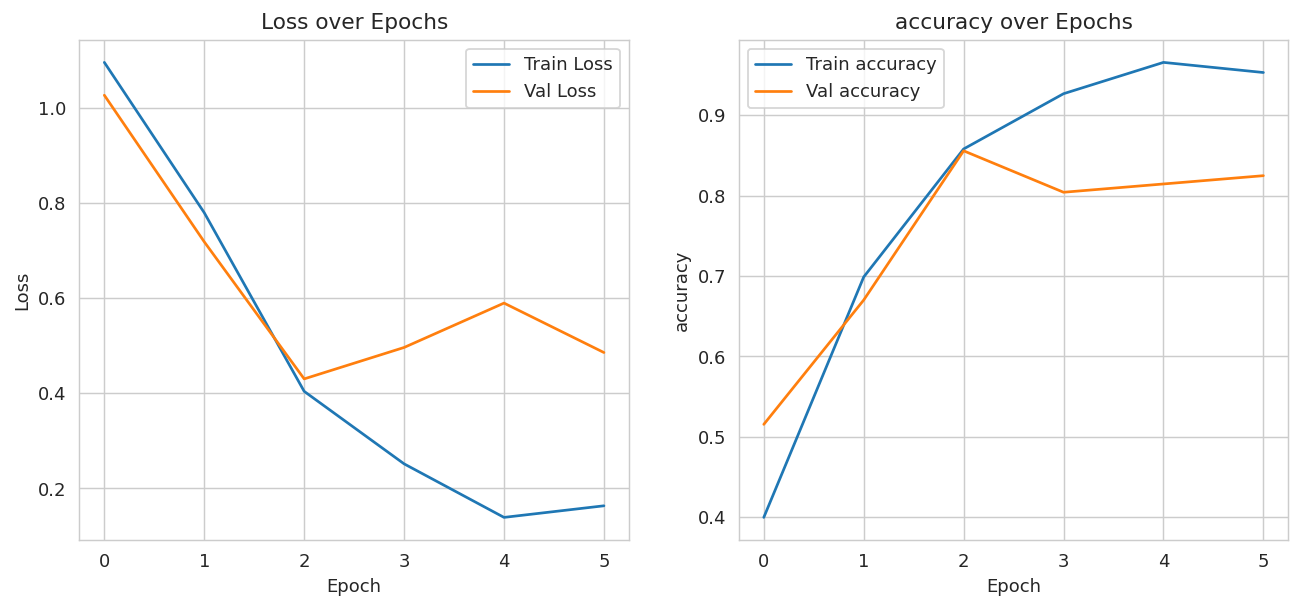

In [51]:
metric_name = config["primary_metric"]

plt.figure(figsize=(12,5))

# ----- LOSS -----
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# ----- METRIC -----
plt.subplot(1,2,2)
plt.plot(train_metrics, label=f'Train {metric_name}')
plt.plot(val_metrics, label=f'Val {metric_name}')
plt.xlabel('Epoch')
plt.ylabel(metric_name)
plt.title(f'{metric_name} over Epochs')
plt.legend()

wandb.log({"training_curves": wandb.Image(plt)})

plt.show()

After first training phase, I got these results:
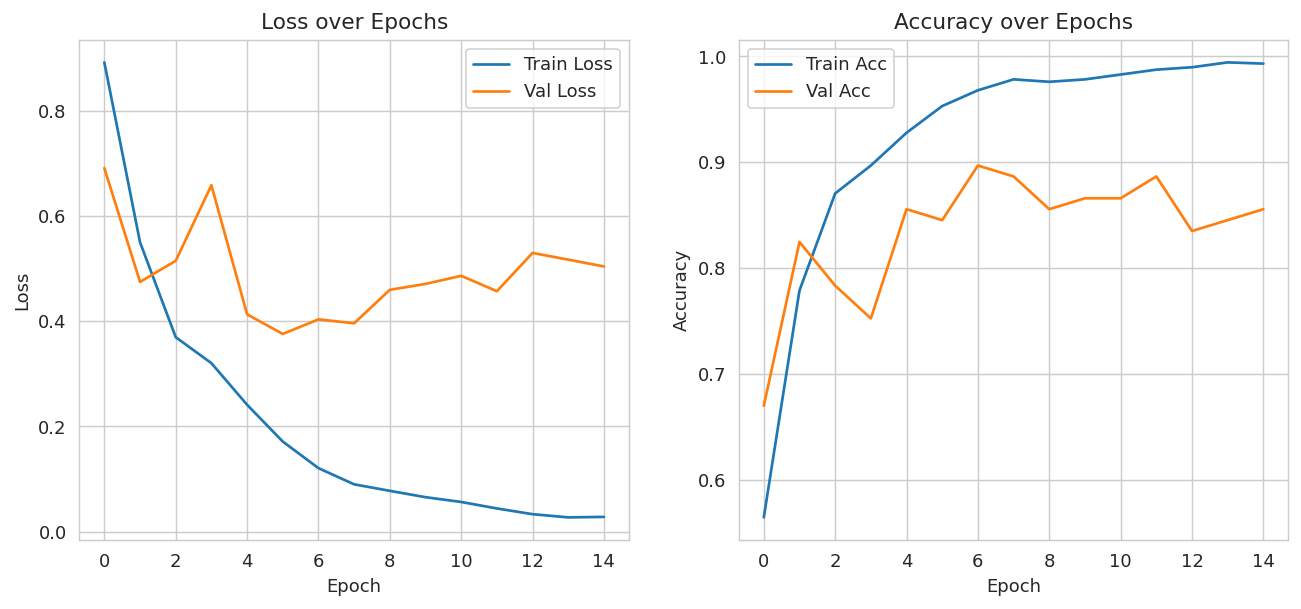
Best model saved with val_acc=0.8969

As we can see, model is getting overfitted, because trainig loss is rapidly decreasing, while validation stays almost the same through all epochs. Also validation accuracy has strange jumps

After making small changes:
1. added weight decay
2. embedding size for cat features 16->8
3. increasing dropout 0.1->0.3
4. added early stopping
I have these results:
Best model - Val Acc: 0.8660, Val Loss: 0.3685
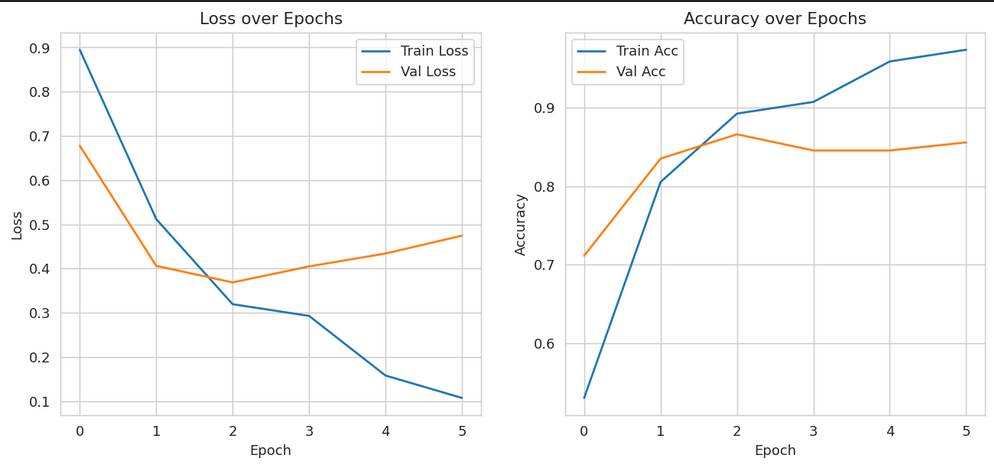


After adding another linear layer I got almost no improvement:
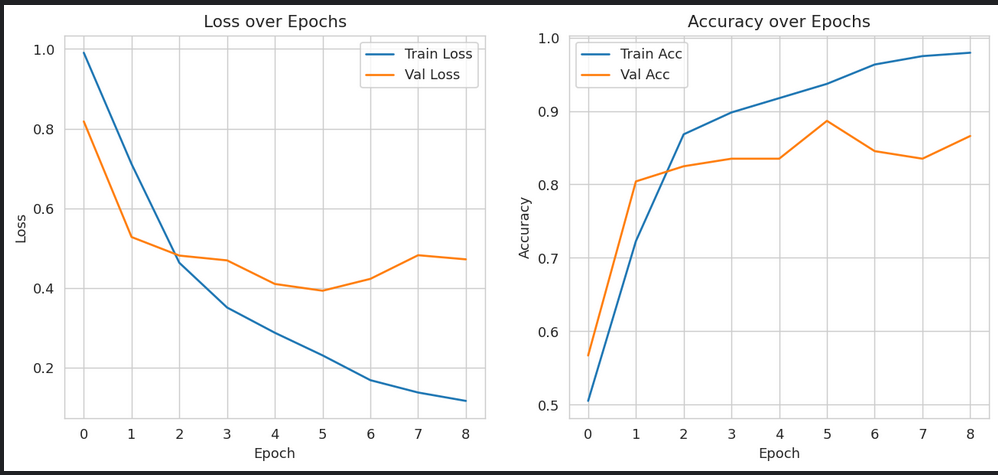
🛑 Early stopping triggered after 9 epochs!
Best model - Val Acc: 0.8866, Val Loss: 0.3933

Last hope is to increase/decrease lr

After decreasing learning rate I got these results:
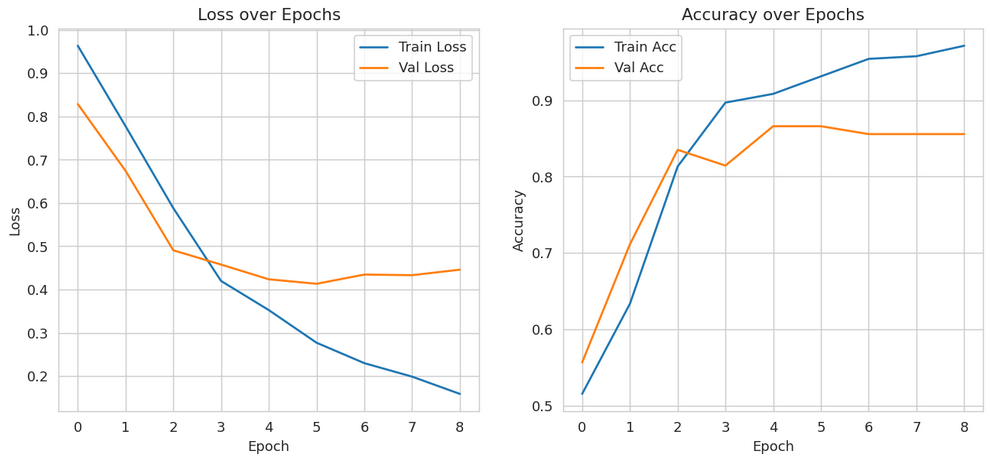

🛑 Early stopping triggered after 9 epochs!
Best model - Val Acc: 0.8660, Val Loss: 0.4133

Basically I can stop here and get ~0.85 accuracy on test data. Hovewer, I identified that there is STRONG disbalance in target classes (small amount of positive sentiment). Thus, I can tr to overcome overfitting problem using weighted loss

After using weighted loss, I got more or less stable and better result:
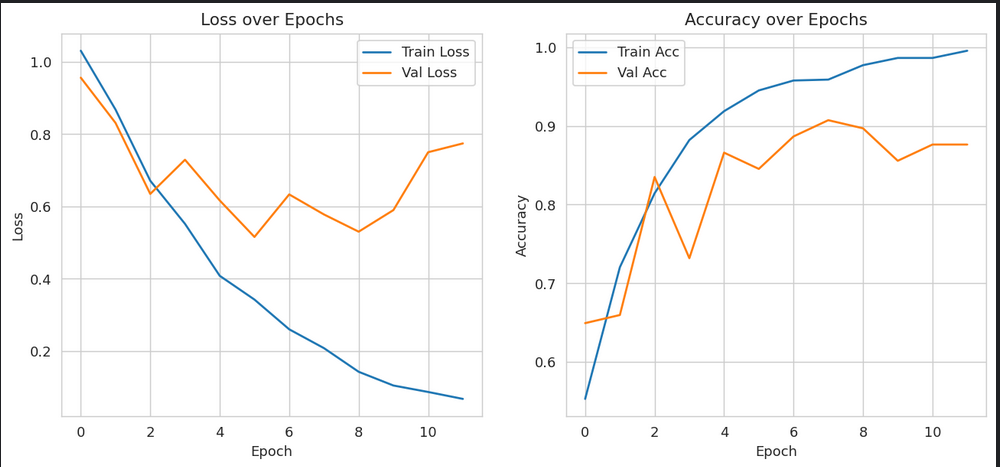
🛑 Early stopping triggered after 12 epochs!
Best model - Val Acc: 0.8969, Val Loss: 0.5302

Let's see confusion matrix

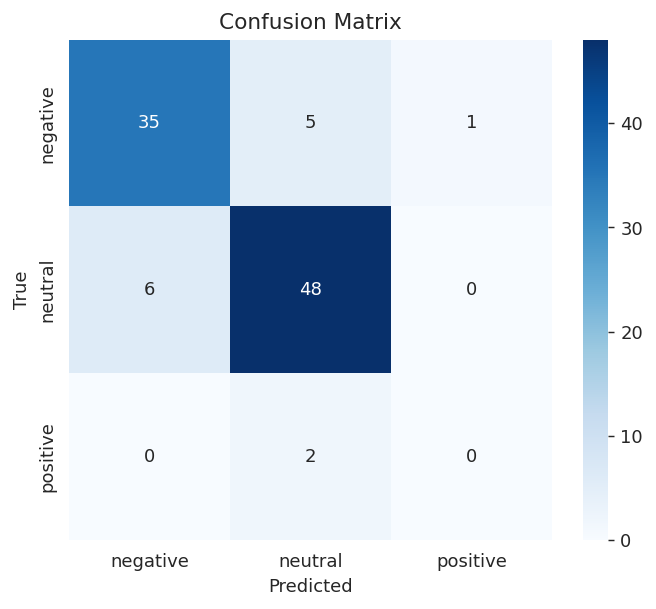

              precision    recall  f1-score   support

    negative       0.85      0.85      0.85        41
     neutral       0.87      0.89      0.88        54
    positive       0.00      0.00      0.00         2

    accuracy                           0.86        97
   macro avg       0.58      0.58      0.58        97
weighted avg       0.85      0.86      0.85        97



In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch.get('token_type_ids', None)
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        cat_features = batch['cat_features'].to(device)
        labels = batch['labels'].to(device)

        logits = model(input_ids, attention_mask, cat_features, token_type_ids)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative","neutral","positive"],
    yticklabels=["negative","neutral","positive"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

wandb.log({"final_confusion_matrix": wandb.Image(plt)})

plt.show()


# ---- Classification Report ----
report = classification_report(
        all_labels,
        all_preds,
        target_names=["negative","neutral","positive"])
print(
    report
)

wandb.log({"classification_report": report})

In [53]:
wandb.finish()
print(f"Experiment {config['experiment_name']} completed!")

wandb: updating run metadata
wandb: uploading history steps 5-8, summary, console lines 37-54
wandb: 
wandb: Run history:
wandb:          epoch ▁▂▄▅▇█
wandb:  learning_rate ▁█▆▅▃▁
wandb: train_accuracy ▁▅▇███
wandb:     train_loss █▆▃▂▁▁
wandb:   val_accuracy ▁▄█▇▇▇
wandb:       val_loss █▄▁▂▃▂
wandb: 
wandb: Run summary:
wandb: classification_report               precis...
wandb:                 epoch 6
wandb:         learning_rate 1e-05
wandb:        train_accuracy 0.95304
wandb:            train_loss 0.16338
wandb:          val_accuracy 0.82474
wandb:              val_loss 0.48563
wandb: 
wandb: 🚀 View run exp17_extra_layer at: https://wandb.ai/e278979-metu-middle-east-technical-university/odtu-transformer-assignment/runs/bhb98wpg
wandb: ⭐️ View project at: https://wandb.ai/e278979-metu-middle-east-technical-university/odtu-transformer-assignment
wandb: Synced 5 W&B file(s), 2 media file(s), 0 artifact file(s) and 1 other file(s)
wandb: Find logs at: ./wandb/run-20260312_184918-bhb9

Experiment exp17_extra_layer completed!


Results are sad, but predictable. Unfortunanly, due to HUGE imbalance it train and validations data, model actually do not see nad do no learn anything about positive class. It is sad, but to be honest predictable, that weighted loss could not help with such big imbalance. It does matter, because in test data classes are balanced. So, there is 2 ways to overcome that issue: weighted random sampling and duplicating positive sentiments in batches. It is obvious that 1st way is better :)

## Test

## Save & conclusion